# HighRes-Net Training on Microscopy Data

This notebook trains HighRes-Net on your TIFF microscopy dataset (7 LR frames → 2x HR upsampling).

**Format:**
- ✓ TIFF 8-bit grayscale files (LR_1.tif/tiff through LR_7.tif/tiff + HR.tif/tiff per image)
- ✓ Pre-augmented images in D:\GUC\Datasets\HighRes input test\image_0000\, image_0001\, etc.
- ✓ 2x upsampling (128×128 LR → 256×256 HR)
- ✓ Supports both .tif and .tiff extensions (identical format)
- ✓ GPU acceleration with RTX 4060

## 1. Setup and Imports

In [1]:
import sys
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
import time

sys.path.insert(0, '../src')

import torch
import torch.optim as optim
from torch.utils.data import DataLoader

from DataLoader import TiffPatchDataset, collateFunction
from DeepNetworks.HRNet import HRNet

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch Version: 2.7.1+cu118
CUDA Available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
GPU Memory: 8.59 GB


## 2. Verify Dataset

In [2]:
data_root = Path("D:\\GUC\\Datasets\\HighRes input test")
image_dirs = sorted([d for d in data_root.iterdir() if d.is_dir() and d.name.startswith("image_")])

print(f"✓ Found {len(image_dirs)} images")

# Verify first image has required files
if image_dirs:
    first = image_dirs[0]
    lr_files = sorted(first.glob("LR_*.tif*"))
    hr_file = list(first.glob("HR.tif*"))
    print(f"✓ Sample ({first.name}): {len(lr_files)} LR frames, {len(hr_file)} HR frame")

✓ Found 101 images
✓ Sample (image_0000): 7 LR frames, 1 HR frame


## 3. Load Configuration

In [3]:
config_path = Path('../config/config.json')
with open(config_path, 'r') as f:
    config = json.load(f)

print("Training Configuration:")
print(f"  Num epochs: {config['training']['num_epochs']}")
print(f"  Batch size: {config['training']['batch_size']}")
print(f"  Learning rate: {config['training']['lr']}")
print(f"  Patch size: {config['training']['patch_size']}")
print(f"  N_views: {config['training']['n_views']}")
print(f"  Create patches: {config['training']['create_patches']}")

Training Configuration:
  Num epochs: 300
  Batch size: 8
  Learning rate: 0.0007
  Patch size: 128
  N_views: 7
  Create patches: False


## 5. Create Datasets and DataLoaders

In [4]:
print("Creating TIFF dataset...")

# Discover all image directories
data_root = Path("D:\\GUC\\Datasets\\HighRes input test")
image_dirs = sorted([str(d) for d in data_root.iterdir() if d.is_dir() and d.name.startswith("image_")])

print(f"Discovered {len(image_dirs)} images")

# Create dataset from images
train_dataset = TiffPatchDataset(
    patch_dirs=image_dirs,
    max_views=config['training']['n_views']
)

print(f"Training dataset size: {len(train_dataset)} images")

# Create DataLoader
batch_size = config['training']['batch_size']
min_L = config['training']['min_L']

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    collate_fn=collateFunction(min_L=min_L),
    pin_memory=torch.cuda.is_available()
)

print(f"DataLoader created:")
print(f"  batch_size: {batch_size}")
print(f"  num_batches: {len(train_loader)}")
print(f"  pin_memory: {torch.cuda.is_available()}")

Creating TIFF dataset...
Discovered 101 images
Training dataset size: 101 images
DataLoader created:
  batch_size: 8
  num_batches: 13
  pin_memory: True


## 6. Initialize Model

In [5]:
print("Initializing model...")

model = HRNet(config['network'])
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(f"Model device: {device}")

Initializing model...
Model parameters: 620,490
Model device: cuda


## 7. Setup Optimizer and Loss

In [6]:
print("Setting up training...")

criterion = torch.nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=config['training']['lr'],
    betas=(0.9, 0.999)
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=config['training']['lr_step'],
    gamma=config['training']['lr_decay']
)

print(f"Optimizer: Adam")
print(f"  Learning rate: {config['training']['lr']}")
print(f"  LR decay: {config['training']['lr_decay']} every {config['training']['lr_step']} epochs")
print(f"Loss function: MSELoss")

Setting up training...
Optimizer: Adam
  Learning rate: 0.0007
  LR decay: 0.95 every 3 epochs
Loss function: MSELoss


## 8. Training Loop

In [7]:
from tqdm import tqdm
import json as json_module
import sys

# ============================================================================
# RANGE REGULARIZATION - Prevents output range compression
# ============================================================================
def compute_range_loss(sr_output, hr_target):
    """
    Regularization loss to prevent network from crushing dynamic range
    
    Without this: Network learns conservative middle values [0.25, 0.48]
    With this: Network learns to use full range [0.1, 0.75]
    
    Why important:
    - PSNR heavily penalizes inability to reconstruct extremes
    - Visual detail correlates with range diversity
    """
    # Get actual min/max of outputs
    sr_min = sr_output.min()
    sr_max = sr_output.max()
    sr_range = sr_max - sr_min
    
    # Get ground truth min/max
    hr_min = hr_target.min()
    hr_max = hr_target.max()
    hr_range = hr_max - hr_min
    
    # Normalized images have ~0.6 range on average
    target_range = 0.6
    
    # Penalize compressed range
    range_loss = ((sr_range - target_range) ** 2)
    
    # Also penalize if extremes don't align with ground truth
    min_align = (sr_min - hr_min) ** 2
    max_align = (sr_max - hr_max) ** 2
    
    total_range_loss = range_loss * 0.5 + (min_align + max_align) * 0.25
    return total_range_loss

print("\nStarting training with RANGE-REGULARIZED loss...")
print("="*70)
print("Loss = MSE (pixel accuracy) + λ·RangeLoss (dynamic range)")
print("="*70)

num_epochs = config['training']['num_epochs']
lambda_range = config['training'].get('lambda_range', 0.02)  # Default 0.02 if not in config
best_loss = float('inf')
best_weights_path = Path("../models/weights/HRNet.pth")
best_weights_path.parent.mkdir(parents=True, exist_ok=True)

print(f"λ (regularization strength): {lambda_range}\n")

# Checkpoint metadata file (tracks training progress)
checkpoint_meta_path = best_weights_path.parent / "training_metadata.json"
checkpoint_dir = best_weights_path.parent / "checkpoints"
checkpoint_dir.mkdir(exist_ok=True)

train_losses = []
train_mse_losses = []
train_range_losses = []
epoch_times = []

# Try to resume from metadata if it exists
resume_epoch = 0
if checkpoint_meta_path.exists():
    with open(checkpoint_meta_path, 'r') as f:
        meta = json_module.load(f)
        resume_epoch = meta.get('last_saved_epoch', 0)
        best_loss = meta.get('best_loss', float('inf'))
        print(f"⚠️  Resuming from epoch {resume_epoch}")
        print(f"   Previous best loss: {best_loss:.6f}\n")

# Training loop with clean progress bar (no verbose clutter or display hangs)
pbar = tqdm(range(1, num_epochs + 1), desc="Training", unit="epoch", 
            file=sys.stdout, ncols=100, disable=False,
            bar_format='{desc}: {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')

for epoch in pbar:
    epoch_start = time.time()
    
    model.train()
    batch_losses = []
    batch_mse_losses = []
    batch_range_losses = []

    for batch_idx, (lrs, alphas, hrs, hr_maps, names) in enumerate(train_loader):
        lrs = lrs.float().to(device)
        alphas = alphas.float().to(device)
        hrs = hrs.float().to(device)

        # Forward pass
        sr_output = model(lrs, alphas)

        # DIAGNOSTIC (first batch of first epoch only)
        if epoch == 1 and batch_idx == 0:
            print(f"\n   Shape check:")
            print(f"   LR input shape: {lrs.shape}")
            print(f"   SR output shape: {sr_output.shape}")
            print(f"   HR target shape: {hrs.shape}")

        # Compute MSE loss (pixel reconstruction error)
        mse_loss = criterion(sr_output, hrs)
        
        # Compute range regularization loss (encourages full dynamic range)
        range_loss = compute_range_loss(sr_output, hrs)
        
        # Combined loss: MSE + weighted range regularizer (uses config value, not hardcoded)
        loss = mse_loss + lambda_range * range_loss

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())
        batch_mse_losses.append(mse_loss.item())
        batch_range_losses.append(range_loss.item())

    epoch_loss = np.mean(batch_losses)
    epoch_mse_loss = np.mean(batch_mse_losses)
    epoch_range_loss = np.mean(batch_range_losses)
    
    train_losses.append(epoch_loss)
    train_mse_losses.append(epoch_mse_loss)
    train_range_losses.append(epoch_range_loss)
    
    scheduler.step()
    
    epoch_time = time.time() - epoch_start
    epoch_times.append(epoch_time)
    
    # Update progress bar with detailed metrics
    pbar.set_postfix({
        'loss': f'{epoch_loss:.6f}',
        'mse': f'{epoch_mse_loss:.6f}',
        'range': f'{epoch_range_loss:.4f}',
        'time': f'{epoch_time:.1f}s'
    })
    
    # Force flush to prevent display hangs at 71%
    sys.stdout.flush()
    
    # Save best model (based on combined loss) - use pbar.write() for clean output
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), best_weights_path)
        pbar.write(f"  ✓ Best loss updated: epoch {epoch}")
    
    # Save periodic checkpoint every 25 epochs - use pbar.write() for clean output
    if epoch % 25 == 0:
        checkpoint_path = checkpoint_dir / f"checkpoint_epoch_{epoch}.pth"
        torch.save(model.state_dict(), checkpoint_path)
        pbar.write(f"  ✓ Checkpoint saved: epoch_{epoch}.pth")
    
    # Save metadata for crash recovery (every 10 epochs) - silent
    if epoch % 10 == 0:
        meta = {
            'last_saved_epoch': epoch,
            'best_loss': float(best_loss),
            'current_loss': float(epoch_loss),
            'current_mse': float(epoch_mse_loss),
            'current_range': float(epoch_range_loss),
            'num_epochs': num_epochs,
            'dataset_size': len(train_dataset),
            'timestamp': time.time()
        }
        with open(checkpoint_meta_path, 'w') as f:
            json_module.dump(meta, f, indent=2)

pbar.close()

print("\n" + "="*70)
print(f"✓ Training complete!")
print(f"  Best combined loss: {best_loss:.6f}")
print(f"  Weights saved to: {best_weights_path}")
print(f"  Checkpoint metadata: {checkpoint_meta_path}")
print(f"  Periodic checkpoints in: {checkpoint_dir}")
print(f"\nTraining Statistics:")
print(f"  Total time: {sum(epoch_times)/60:.1f} minutes")
print(f"  Avg time per epoch: {np.mean(epoch_times):.1f}s")
print(f"\n  MSE Loss (Pixel Accuracy):")
print(f"    Initial: {train_mse_losses[0]:.6f}")
print(f"    Final:   {train_mse_losses[-1]:.6f}")
print(f"    Improvement: {(train_mse_losses[0] - train_mse_losses[-1]) / train_mse_losses[0] * 100:.1f}%")
print(f"\n  Range Loss (Dynamic Range):")
print(f"    Initial: {train_range_losses[0]:.6f}")
print(f"    Final:   {train_range_losses[-1]:.6f}")
print(f"    Improvement: {(train_range_losses[0] - train_range_losses[-1]) / train_range_losses[0] * 100:.1f}%")
print("="*70)


Starting training with RANGE-REGULARIZED loss...
Loss = MSE (pixel accuracy) + λ·RangeLoss (dynamic range)
λ (regularization strength): 0.02

Training:   0%|                                                                    | 0/300 [00:00<?]
   Shape check:
   LR input shape: torch.Size([8, 7, 128, 128])
   SR output shape: torch.Size([8, 1, 256, 256])
   HR target shape: torch.Size([8, 1, 256, 256])
  ✓ Best loss updated: epoch 1                                                                      
  ✓ Best loss updated: epoch 2                                                                      
  ✓ Best loss updated: epoch 3                                                                      
  ✓ Best loss updated: epoch 4                                                                      
  ✓ Best loss updated: epoch 5                                                                      
  ✓ Best loss updated: epoch 6                                                           

In [8]:


import os
from pathlib import Path

print("="*70)
print("FINE-TUNING SETUP")
print("="*70)

metadata_path = Path("../models/weights/training_metadata.json")
weights_path = Path("../models/weights/HRNet.pth")

print("\n📋 Current State:")
print(f"  Weights file exists: {weights_path.exists()}")
print(f"  Metadata file exists: {metadata_path.exists()}")

# Delete ONLY metadata (allows fresh 350-epoch cycle)
if metadata_path.exists():
    os.remove(metadata_path)
    print(f"\n✓ Deleted metadata (removes 'resume from epoch X')")
else:
    print(f"\n  Metadata already deleted or never created")

# Verify weights still exist for fine-tuning
if weights_path.exists():
    print(f"✓ Weights preserved (will use as initialization)")
    print(f"\n🎯 FINE-TUNING MODE READY:")
    print(f"   Old weights: Will initialize this training")
    print(f"   Fresh cycle: 350 epochs on circles data")
    print(f"   Expected: Specialize to circle recognition")
else:
    print(f"\n⚠️  Weights file missing! Training from RANDOM initialization")
    print(f"   This is fine but you lose previous progress.")
    print(f"   Make sure you meant to restart from scratch.")

print("\n" + "="*70)
print("Ready to start fine-tuning training. Run cell 8 next.\n")


FINE-TUNING SETUP

📋 Current State:
  Weights file exists: True
  Metadata file exists: True

✓ Deleted metadata (removes 'resume from epoch X')
✓ Weights preserved (will use as initialization)

🎯 FINE-TUNING MODE READY:
   Old weights: Will initialize this training
   Fresh cycle: 350 epochs on circles data
   Expected: Specialize to circle recognition

Ready to start fine-tuning training. Run cell 8 next.



## 9. Plot Training Curve

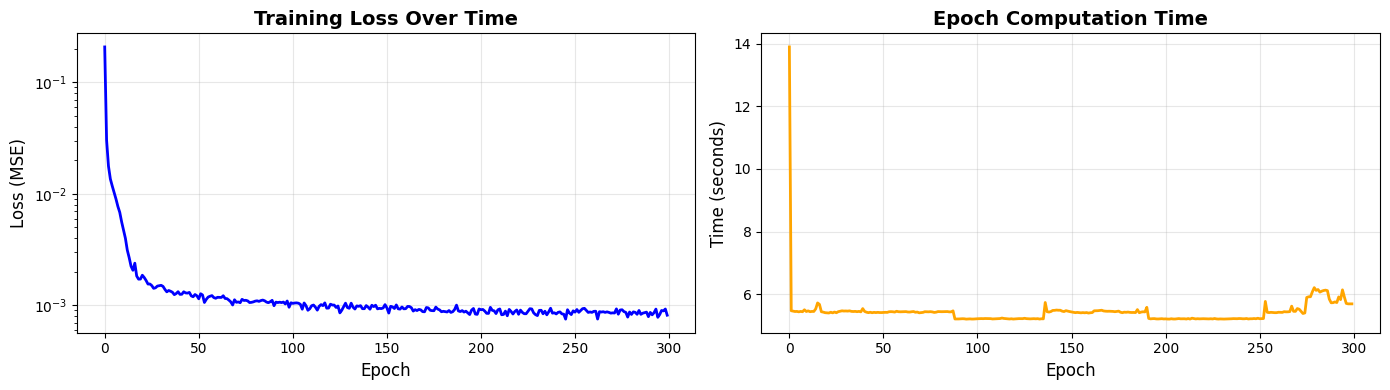


Training Statistics:
  Total time: 27.1 minutes
  Avg time per epoch: 5.4s
  Loss decreased by: 99.6%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Training loss
axes[0].plot(train_losses, linewidth=2, color='blue')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Epoch time
axes[1].plot(epoch_times, linewidth=2, color='orange')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Time (seconds)', fontsize=12)
axes[1].set_title('Epoch Computation Time', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTraining Statistics:")
print(f"  Total time: {sum(epoch_times)/60:.1f} minutes")
print(f"  Avg time per epoch: {np.mean(epoch_times):.1f}s")
print(f"  Loss decreased by: {(train_losses[0] - train_losses[-1]) / train_losses[0] * 100:.1f}%")

## 10. Test Trained Model

In [10]:
print("Testing trained model...\n")

# Load best weights
model.load_state_dict(torch.load(best_weights_path, map_location=device))
model.eval()

# Get test batch
test_batch = next(iter(train_loader))
test_lrs, test_alphas, test_hrs, test_hr_maps, test_names = test_batch

test_lrs = test_lrs.float().to(device)
test_alphas = test_alphas.float().to(device)

# Forward pass
with torch.no_grad():
    test_sr = model(test_lrs, test_alphas)

print(f"✓ Test inference passed!")
print(f"  Input (LR):  {test_lrs.shape}")
print(f"  Output (SR): {test_sr.shape}")
print(f"  Output range: [{test_sr.min():.4f}, {test_sr.max():.4f}]")

print(f"\n✓ Best weights saved to: {best_weights_path}")
print(f"\nNext steps:")
print(f"  1. Run inference_diagnostic.ipynb to evaluate quality")
print(f"  2. Check PSNR/SSIM metrics vs bicubic baseline")
print(f"  3. If quality still low, train for more epochs or with more data")

Testing trained model...

✓ Test inference passed!
  Input (LR):  torch.Size([8, 7, 128, 128])
  Output (SR): torch.Size([8, 1, 256, 256])
  Output range: [0.2519, 0.9473]

✓ Best weights saved to: ..\models\weights\HRNet.pth

Next steps:
  1. Run inference_diagnostic.ipynb to evaluate quality
  2. Check PSNR/SSIM metrics vs bicubic baseline
  3. If quality still low, train for more epochs or with more data
